# GSE193336 - Human monocyte-derived macrophages projected into ARCHS4 and GTEx

**Environment:** `clamp-analyses`

Projects the GEO processed RNA-seq counts for human monocyte-derived macrophages into two existing CLAMP Hallmark models:

- ARCHS4: `output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/CLAMPfull_hall.rds`
- GTEx: `output/01_model_building/02_gtex/10_CLAMP_hall/CLAMPfull_hall.rds`

The notebook uses the GEO-provided raw gene count matrix, normalizes it for CLAMP projection, and runs paired contrasts on the projected LV scores only. No new CLAMP model is trained and no gene-level differential expression analysis is run.

It also annotates selected shifted LVs with model-specific PhenoMeXcan traits:

- ARCHS4 traits: `data/archs4/traits/hall_coverage_rs100_seed_1_CLAMPfull_hall/gls-summary-phenomexcan.tsv.gz`
- GTEx traits: `output/01_model_building/02_gtex/01_CLAMP/gls-summary-phenomexcan.tsv.gz`

Experimental design from GEO: 4 donors, unstimulated and 50 ng/ml LPS for 24 hours.

## Libraries

In [48]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(here)
  library(CLAMP)
  library(ggplot2)
  library(ggrepel)
  library(org.Hs.eg.db)
  library(AnnotationDbi)
  library(limma)
})


## Paths and thresholds

In [49]:
out_dir         <- here("output", "03_model_biology", "00_archs4", "03_tissue_projections", "03_human_monocyte_derived_macrophages_GSE193336")
data_dir        <- file.path(out_dir, "data")
projection_dir  <- file.path(out_dir, "projections")
results_dir     <- file.path(out_dir, "results")
figure_dir      <- file.path(out_dir, "figures")

for (dir_i in c(data_dir, projection_dir, results_dir, figure_dir)) {
  dir.create(dir_i, recursive = TRUE, showWarnings = FALSE)
}

GEO_ACCESSION <- "GSE193336"
LV_FDR_CUTOFF <- 0.05
LV_LOGFC_CUTOFF <- 0.10
PATHWAY_FDR_CUTOFF <- 0.05
PATHWAY_AUC_CUTOFF <- 0.70

model_paths <- list(
  ARCHS4 = here("output", "01_model_building", "04_archs4", "06_bp_coverage_rshall", "06_bp_coverage_hall_rs_100", "hall_coverage_rs100_seed_1", "CLAMPfull_hall.rds"),
  GTEx   = here("output", "01_model_building", "02_gtex", "10_CLAMP_hall", "CLAMPfull_hall.rds")
)

trait_paths <- list(
  ARCHS4 = here("data", "archs4", "traits", "hall_coverage_rs100_seed_1_CLAMPfull_hall", "gls-summary-phenomexcan.tsv.gz"),
  GTEx   = here("data", "gtex", "phenoplier", "gls-summary-phenomexcan.tsv.gz")
)

TRAIT_FDR_CUTOFF <- 0.05

list(models = model_paths, traits = trait_paths)


$models
$models$ARCHS4
[1] "/home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/CLAMPfull_hall.rds"

$models$GTEx
[1] "/home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/02_gtex/10_CLAMP_hall/CLAMPfull_hall.rds"


$traits
$traits$ARCHS4
[1] "/home/msubirana/Documents/pivlab/clamp-analyses/data/archs4/traits/hall_coverage_rs100_seed_1_CLAMPfull_hall/gls-summary-phenomexcan.tsv.gz"

$traits$GTEx
[1] "/home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/02_gtex/01_CLAMP/gls-summary-phenomexcan.tsv.gz"

## General helpers

In [50]:
clean_pathway <- function(x) {
  x <- ifelse(is.na(x) | x == "", "unannotated", x)
  x <- gsub("^HALL_HALLMARK_", "", x)
  x <- gsub("^HALLMARK_", "", x)
  x <- gsub("^REACTOME_REACTOME_", "", x)
  x <- gsub("^REACTOME_", "", x)
  x <- gsub("^GOBP_GOBP_|^GOCC_GOCC_|^GOMF_GOMF_", "", x)
  x <- gsub("^GOBP_|^GOCC_|^GOMF_", "", x)
  x <- gsub("^C[0-9]+_", "", x)
  x <- gsub("_", " ", x)
  trimws(gsub("\\s+", " ", x))
}

wrap_label <- function(x, width = 45) {
  vapply(
    x,
    function(s) paste(strwrap(s, width = width), collapse = "\n"),
    character(1),
    USE.NAMES = FALSE
  )
}

empty_plot <- function(label) {
  ggplot() +
    theme_void() +
    annotate("text", x = 0.5, y = 0.5, label = label,
             size = 4, colour = "grey55", hjust = 0.5)
}


## Download and load GSE193336 counts

In [51]:
raw_path <- file.path(data_dir, "GSE193336_GEO_Processed_Data_Raw_Count_Macrophage.csv.gz")
geo_url <- paste0(
  "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE193nnn/GSE193336/suppl/",
  "GSE193336_GEO_Processed_Data_Raw_Count_Macrophage.csv.gz"
)

if (!file.exists(raw_path)) {
  download.file(geo_url, raw_path, mode = "wb", quiet = FALSE)
} else {
  message("Using cached file: ", basename(raw_path))
}

counts_dt <- fread(raw_path)
gene_col <- colnames(counts_dt)[1]

counts_ens <- as.matrix(counts_dt[, -1, with = FALSE])
storage.mode(counts_ens) <- "numeric"
rownames(counts_ens) <- counts_dt[[gene_col]]

cat("Raw GEO matrix:", nrow(counts_ens), "genes x", ncol(counts_ens), "samples\n")
colnames(counts_ens)


Using cached file: GSE193336_GEO_Processed_Data_Raw_Count_Macrophage.csv.gz



Raw GEO matrix: 58825 genes x 8 samples


[1] "donor 1_unstim" "donor 1_LPS"    "donor 2_unstim" "donor 2_LPS"   
[5] "donor 3_unstim" "donor 3_LPS"    "donor 4_unstim" "donor 4_LPS"

## Build sample metadata

In [52]:
gsm_map <- c(
  "donor 1_unstim" = "GSM5792562",
  "donor 1_LPS"    = "GSM5792563",
  "donor 2_unstim" = "GSM5792564",
  "donor 2_LPS"    = "GSM5792565",
  "donor 3_unstim" = "GSM5792566",
  "donor 3_LPS"    = "GSM5792567",
  "donor 4_unstim" = "GSM5792568",
  "donor 4_LPS"    = "GSM5792569"
)

meta_mac <- data.frame(
  sample    = colnames(counts_ens),
  gsm       = unname(gsm_map[colnames(counts_ens)]),
  donor     = sub("^(donor [0-9]+)_.*$", "\\1", colnames(counts_ens)),
  condition = ifelse(grepl("_LPS$", colnames(counts_ens)), "LPS", "Untreated"),
  stringsAsFactors = FALSE
)
meta_mac$treatment <- ifelse(meta_mac$condition == "LPS",
                             "50 ng/ml LPS for 24 hours", "Unstimulated")

stopifnot(!any(is.na(meta_mac$gsm)))
write.csv(meta_mac, file.path(data_dir, "GSE193336_metadata.csv"), row.names = FALSE)

print(meta_mac)
print(table(meta_mac$donor, meta_mac$condition))


          sample        gsm   donor condition                 treatment
1 donor 1_unstim GSM5792562 donor 1 Untreated              Unstimulated
2    donor 1_LPS GSM5792563 donor 1       LPS 50 ng/ml LPS for 24 hours
3 donor 2_unstim GSM5792564 donor 2 Untreated              Unstimulated
4    donor 2_LPS GSM5792565 donor 2       LPS 50 ng/ml LPS for 24 hours
5 donor 3_unstim GSM5792566 donor 3 Untreated              Unstimulated
6    donor 3_LPS GSM5792567 donor 3       LPS 50 ng/ml LPS for 24 hours
7 donor 4_unstim GSM5792568 donor 4 Untreated              Unstimulated
8    donor 4_LPS GSM5792569 donor 4       LPS 50 ng/ml LPS for 24 hours


         
          LPS Untreated
  donor 1   1         1
  donor 2   1         1
  donor 3   1         1
  donor 4   1         1


## Convert Ensembl IDs to HGNC symbols and normalize

In [53]:
counts_sym_path <- file.path(data_dir, "GSE193336_counts_hgnc.rds")
norm_path       <- file.path(data_dir, "GSE193336_norm_clamp.rds")

if (!file.exists(norm_path)) {
  ids_clean <- sub("\\..*", "", rownames(counts_ens))
  hgnc_ids <- AnnotationDbi::mapIds(
    org.Hs.eg.db,
    keys = unique(ids_clean),
    column = "SYMBOL",
    keytype = "ENSEMBL",
    multiVals = "first"
  )
  hgnc_vec <- unname(hgnc_ids[ids_clean])

  keep <- !is.na(hgnc_vec) & hgnc_vec != ""
  counts_mac <- counts_ens[keep, , drop = FALSE]
  rownames(counts_mac) <- hgnc_vec[keep]
  counts_mac <- rowsum(counts_mac, rownames(counts_mac))

  cpm_mac  <- cpmCLAMP(counts_mac)
  prep_mac <- preprocessCLAMP(Y = cpm_mac, mean_cutoff = 0.5, var_cutoff = 0.1)
  norm_mac <- zscoreCLAMP(Y_filtered = prep_mac$Y_filtered,
                          rowStats = prep_mac$rowStats)

  saveRDS(counts_mac, counts_sym_path)
  saveRDS(norm_mac, norm_path)
} else {
  counts_mac <- readRDS(counts_sym_path)
  norm_mac   <- readRDS(norm_path)
}

cat("HGNC count matrix:", nrow(counts_mac), "genes x", ncol(counts_mac), "samples\n")
cat("Normalized matrix:", nrow(norm_mac), "genes x", ncol(norm_mac), "samples\n")


HGNC count matrix: 35932 genes x 8 samples
Normalized matrix: 13289 genes x 8 samples


## Load projection models

In [54]:
read_projection_model <- function(path) {
  mdl <- readRDS(path)
  keep <- list(
    Z = as.matrix(mdl$Z),
    L2 = mdl$L2,
    summary = mdl$summary
  )
  rm(mdl)
  gc()
  keep
}

models <- lapply(model_paths, read_projection_model)

for (model_name in names(models)) {
  mdl <- models[[model_name]]
  n_sig <- sum(mdl$summary$FDR < PATHWAY_FDR_CUTOFF &
                 mdl$summary$AUC > PATHWAY_AUC_CUTOFF,
               na.rm = TRUE)
  cat(model_name, "model - genes:", nrow(mdl$Z),
      "| LVs:", ncol(mdl$Z),
      "| significant pathway annotations:", n_sig, "\n")
}


ARCHS4 model - genes: 18423 | LVs: 1728 | significant pathway annotations: 1794 
GTEx model - genes: 21613 | LVs: 578 | significant pathway annotations: 886 


## Projection and contrast helpers

In [55]:
build_lv_annot <- function(mdl,
                           pathway_fdr_cutoff = PATHWAY_FDR_CUTOFF,
                           auc_cutoff = PATHWAY_AUC_CUTOFF) {
  mdl$summary %>%
    dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
    dplyr::filter(FDR < pathway_fdr_cutoff, AUC > auc_cutoff) %>%
    dplyr::group_by(LV) %>%
    dplyr::arrange(dplyr::desc(AUC), FDR, .by_group = TRUE) %>%
    dplyr::summarise(
      pathways = paste(clean_pathway(pathway), collapse = " | "),
      top_AUC  = max(AUC, na.rm = TRUE),
      n_paths  = dplyr::n(),
      .groups  = "drop"
    )
}

project_model <- function(mdl, norm_mat, model_name) {
  common <- intersect(rownames(mdl$Z), rownames(norm_mat))
  mdl_sub <- list(
    Z = mdl$Z[common, , drop = FALSE],
    L2 = mdl$L2
  )
  B <- projectCLAMP(CLAMPres = mdl_sub,
                    newdata = norm_mat[common, , drop = FALSE])
  cat(model_name, "common genes:", length(common),
      sprintf("(%.1f%% of model genes)\n", 100 * length(common) / nrow(mdl$Z)))
  B
}

rank_lvs_paired <- function(B, meta, mdl, model_name) {
  meta_aligned <- meta[match(colnames(B), meta$sample), , drop = FALSE]
  stopifnot(!any(is.na(meta_aligned$sample)))
  stopifnot(all(meta_aligned$sample == colnames(B)))

  condition <- relevel(factor(meta_aligned$condition), ref = "Untreated")
  donor <- factor(meta_aligned$donor)
  design <- model.matrix(~ donor + condition)
  colnames(design) <- make.names(colnames(design))

  fit <- lmFit(B, design)
  fit <- eBayes(fit)
  de <- topTable(fit, coef = "conditionLPS", n = Inf,
                 adjust.method = "BH", sort.by = "P")
  de$LV <- rownames(de)

  annot <- build_lv_annot(mdl)
  de %>%
    dplyr::left_join(annot, by = "LV") %>%
    dplyr::mutate(
      model = model_name,
      pathways = ifelse(is.na(pathways), "unannotated", pathways),
      top_AUC = ifelse(is.na(top_AUC), 0, top_AUC),
      n_paths = ifelse(is.na(n_paths), 0L, as.integer(n_paths)),
      abs_logFC = abs(logFC),
      direction = dplyr::case_when(
        logFC > 0 ~ "Higher in LPS",
        logFC < 0 ~ "Higher in Untreated",
        TRUE ~ "No shift"
      )
    ) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(abs_logFC))
}

extract_shifted_pathways <- function(lv_ranked, mdl, model_name,
                                     lv_fdr_cutoff = LV_FDR_CUTOFF,
                                     lfc_cutoff = LV_LOGFC_CUTOFF,
                                     pathway_fdr_cutoff = PATHWAY_FDR_CUTOFF,
                                     auc_cutoff = PATHWAY_AUC_CUTOFF) {
  annot <- mdl$summary %>%
    dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
    dplyr::filter(FDR < pathway_fdr_cutoff, AUC > auc_cutoff) %>%
    dplyr::mutate(pathway_clean = clean_pathway(pathway))

  lv_ranked %>%
    dplyr::filter(adj.P.Val < lv_fdr_cutoff, abs_logFC >= lfc_cutoff) %>%
    dplyr::inner_join(annot, by = "LV") %>%
    dplyr::mutate(model = model_name) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(abs_logFC), dplyr::desc(AUC))
}

empty_pathway_summary <- function() {
  data.frame(
    model = character(),
    pathway_clean = character(),
    direction = character(),
    n_lvs = integer(),
    best_AUC = numeric(),
    min_pathway_FDR = numeric(),
    min_lv_FDR = numeric(),
    max_abs_logFC = numeric(),
    mean_logFC = numeric(),
    LVs = character(),
    stringsAsFactors = FALSE
  )
}

summarise_shifted_pathways <- function(pathway_hits) {
  if (nrow(pathway_hits) == 0) return(empty_pathway_summary())
  pathway_hits %>%
    dplyr::group_by(model, pathway_clean, direction) %>%
    dplyr::summarise(
      n_lvs = dplyr::n_distinct(LV),
      best_AUC = max(AUC, na.rm = TRUE),
      min_pathway_FDR = min(FDR, na.rm = TRUE),
      min_lv_FDR = min(adj.P.Val, na.rm = TRUE),
      max_abs_logFC = max(abs_logFC, na.rm = TRUE),
      mean_logFC = mean(logFC, na.rm = TRUE),
      LVs = paste(unique(LV), collapse = ", "),
      .groups = "drop"
    ) %>%
    dplyr::arrange(model, direction, dplyr::desc(max_abs_logFC), min_lv_FDR)
}


## Plot helpers

In [56]:
make_pca_plot <- function(B, meta, title = NULL) {
  pca  <- prcomp(t(B), scale. = TRUE)
  vexp <- round(100 * summary(pca)$importance[2, 1:2], 1)
  df <- as.data.frame(pca$x[, 1:2])
  df$sample <- rownames(df)
  df <- df %>%
    dplyr::left_join(meta, by = "sample")

  ggplot(df, aes(PC1, PC2, color = condition, shape = donor, label = sample)) +
    geom_point(size = 3.4, alpha = 0.9) +
    ggrepel::geom_text_repel(size = 2.8, show.legend = FALSE) +
    scale_color_manual(values = c(Untreated = "#2C7FB8", LPS = "#D95F0E")) +
    labs(title = title,
         x = paste0("PC1 (", vexp[1], "%)"),
         y = paste0("PC2 (", vexp[2], "%)"),
         color = NULL,
         shape = "Donor") +
    theme_bw(base_size = 12)
}

make_volcano <- function(lv_ranked,
                         fdr_cutoff = LV_FDR_CUTOFF,
                         lfc_cutoff = LV_LOGFC_CUTOFF,
                         label_top = 15,
                         title = NULL) {
  df <- lv_ranked %>%
    dplyr::mutate(
      sig = dplyr::case_when(
        adj.P.Val < fdr_cutoff & abs_logFC >= lfc_cutoff & logFC > 0 ~ "Higher in LPS",
        adj.P.Val < fdr_cutoff & abs_logFC >= lfc_cutoff & logFC < 0 ~ "Higher in Untreated",
        TRUE ~ "not selected"
      ),
      neg_log10_fdr = pmin(-log10(pmax(adj.P.Val, .Machine$double.xmin)), 60)
    )

  top_ids <- df %>%
    dplyr::filter(sig != "not selected") %>%
    dplyr::arrange(dplyr::desc(abs_logFC), adj.P.Val) %>%
    dplyr::slice_head(n = label_top) %>%
    dplyr::pull(LV)

  df$label <- ifelse(df$LV %in% top_ids, df$LV, NA_character_)

  ggplot(df, aes(logFC, neg_log10_fdr, color = sig)) +
    geom_hline(yintercept = -log10(fdr_cutoff), linetype = "dashed", color = "grey50") +
    geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dotted", color = "grey40") +
    geom_point(alpha = 0.75, size = 1.8) +
    ggrepel::geom_text_repel(aes(label = label), size = 2.8,
                             max.overlaps = 25, na.rm = TRUE,
                             show.legend = FALSE) +
    scale_color_manual(values = c(
      "Higher in LPS" = "#D95F0E",
      "Higher in Untreated" = "#2C7FB8",
      "not selected" = "grey75"
    )) +
    labs(title = title,
         x = "log2 fold-change (LPS vs untreated)",
         y = "-log10(FDR)",
         color = NULL) +
    theme_bw(base_size = 12)
}

make_pathway_shift_plot <- function(pathway_hits, model_name, top_n_per_direction = 12) {
  if (nrow(pathway_hits) == 0) {
    return(empty_plot(paste(model_name, "no annotated selected LVs")))
  }

  plot_df <- pathway_hits %>%
    dplyr::filter(model == model_name) %>%
    dplyr::group_by(direction) %>%
    dplyr::arrange(dplyr::desc(abs_logFC), adj.P.Val, dplyr::desc(AUC), .by_group = TRUE) %>%
    dplyr::slice_head(n = top_n_per_direction) %>%
    dplyr::ungroup() %>%
    dplyr::mutate(
      label = wrap_label(paste0(LV, " | ", toupper(pathway_clean)), width = 56),
      label = factor(label, levels = rev(unique(label))),
      neg_log10_lv_fdr = -log10(pmax(adj.P.Val, .Machine$double.xmin))
    )

  if (nrow(plot_df) == 0) {
    return(empty_plot(paste(model_name, "no annotated selected LVs")))
  }

  x_lim <- max(abs(plot_df$logFC), na.rm = TRUE) * 1.08
  if (!is.finite(x_lim) || x_lim == 0) x_lim <- 1

  ggplot(plot_df, aes(logFC, label)) +
    geom_vline(xintercept = 0, linetype = "dotted", colour = "grey55") +
    geom_point(aes(size = neg_log10_lv_fdr, colour = direction), alpha = 0.9) +
    scale_colour_manual(values = c(
      "Higher in LPS" = "#D95F0E",
      "Higher in Untreated" = "#2C7FB8"
    ), name = NULL) +
    scale_size_continuous(name = "-log10 LV FDR", range = c(2.5, 7.5)) +
    scale_x_continuous(limits = c(-x_lim, x_lim)) +
    labs(title = paste0(model_name, ": selected shifted pathways"),
         x = "log2 fold-change (LPS vs untreated)",
         y = NULL) +
    theme_bw(base_size = 10) +
    theme(
      plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
      axis.text.y = element_text(size = 7.5, lineheight = 0.9),
      legend.position = "right"
    )
}

make_pathway_comparison_plot <- function(pathway_hits, comparison_tbl, top_n = 20) {
  shared_paths <- comparison_tbl %>%
    dplyr::filter(shared) %>%
    dplyr::arrange(dplyr::desc(max_evidence), pathway_clean) %>%
    dplyr::slice_head(n = top_n) %>%
    dplyr::pull(pathway_clean)

  if (length(shared_paths) == 0) {
    return(empty_plot("no shared selected pathways"))
  }

  plot_df <- pathway_hits %>%
    dplyr::filter(pathway_clean %in% shared_paths) %>%
    dplyr::group_by(model, pathway_clean) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(abs_logFC), dplyr::desc(AUC), .by_group = TRUE) %>%
    dplyr::slice_head(n = 1) %>%
    dplyr::ungroup() %>%
    dplyr::mutate(
      pathway_label = factor(wrap_label(pathway_clean, width = 48),
                             levels = rev(wrap_label(shared_paths, width = 48))),
      model = factor(model, levels = c("ARCHS4", "GTEx"))
    )

  ggplot(plot_df, aes(logFC, pathway_label, color = direction)) +
    geom_vline(xintercept = 0, linetype = "dotted", colour = "grey55") +
    geom_point(size = 3.2, alpha = 0.9) +
    facet_wrap(~ model, ncol = 2) +
    scale_color_manual(values = c(
      "Higher in LPS" = "#D95F0E",
      "Higher in Untreated" = "#2C7FB8"
    )) +
    labs(title = "Shared pathway shifts inferred by both projections",
         x = "representative LV log2 fold-change (LPS vs untreated)",
         y = NULL,
         color = NULL) +
    theme_bw(base_size = 10) +
    theme(
      plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
      strip.background = element_rect(fill = "grey95", colour = "grey70"),
      strip.text = element_text(face = "bold"),
      axis.text.y = element_text(size = 8, lineheight = 0.9),
      legend.position = "right"
    )
}


## Trait helpers

In [57]:
clean_trait_label <- function(text, wrap_w = 46) {
  if (is.na(text) || trimws(text) == "") return(NA_character_)
  text <- trimws(text)

  blacklist <- c("coffee intake", "job code", "none of the above", "tea intake")
  if (any(vapply(blacklist, function(term) grepl(term, tolower(text), fixed = TRUE), logical(1)))) {
    return(NA_character_)
  }

  text <- gsub("^#", "", text)
  text <- gsub("\\s*\\([^)]*?\\d+[^)]*?\\)", "", text, perl = TRUE)
  text <- gsub("_", " ", text)
  text <- trimws(gsub("\\s+", " ", text))
  if (grepl(":", text, fixed = TRUE)) {
    text <- trimws(sub("^.*?:", "", text))
  }
  if (text == "" || any(vapply(blacklist, function(term) grepl(term, tolower(text), fixed = TRUE), logical(1)))) {
    return(NA_character_)
  }

  text <- paste0(toupper(substr(text, 1, 1)), substr(text, 2, nchar(text)))
  paste(strwrap(text, width = wrap_w), collapse = "\n")
}

load_model_traits <- function(path, model_name) {
  traits <- fread(cmd = paste("zcat", shQuote(path))) %>%
    as.data.frame() %>%
    dplyr::select(
      phenotype_id = phenotype,
      phenotype = phenotype_desc,
      LV = lv,
      trait_pvalue = pvalue,
      trait_FDR = fdr
    ) %>%
    dplyr::mutate(
      model = model_name,
      trait_pvalue = as.numeric(trait_pvalue),
      trait_FDR = as.numeric(trait_FDR)
    )
  traits
}

get_related_traits <- function(lv_ranked, traits,
                               trait_fdr_cutoff = TRAIT_FDR_CUTOFF,
                               lv_fdr_cutoff = LV_FDR_CUTOFF,
                               lfc_cutoff = LV_LOGFC_CUTOFF) {
  selected <- lv_ranked %>%
    dplyr::filter(adj.P.Val < lv_fdr_cutoff, abs_logFC >= lfc_cutoff) %>%
    dplyr::select(LV, logFC, adj.P.Val, abs_logFC, direction, pathways, top_AUC, n_paths)

  if (nrow(selected) == 0) return(data.frame())

  traits %>%
    dplyr::filter(LV %in% selected$LV, trait_FDR < trait_fdr_cutoff) %>%
    dplyr::inner_join(selected, by = "LV") %>%
    dplyr::mutate(
      label_clean = vapply(phenotype, clean_trait_label, character(1)),
      trait_neg_log_fdr = -log10(pmax(trait_FDR, .Machine$double.xmin)),
      lv_neg_log_fdr = -log10(pmax(adj.P.Val, .Machine$double.xmin))
    ) %>%
    dplyr::filter(!is.na(label_clean)) %>%
    dplyr::arrange(model, trait_FDR, adj.P.Val, dplyr::desc(abs_logFC))
}

empty_trait_summary <- function() {
  data.frame(
    model = character(),
    phenotype_id = character(),
    phenotype = character(),
    direction = character(),
    n_lvs = integer(),
    best_trait_FDR = numeric(),
    best_trait_pvalue = numeric(),
    min_lv_FDR = numeric(),
    max_abs_logFC = numeric(),
    mean_logFC = numeric(),
    LVs = character(),
    stringsAsFactors = FALSE
  )
}

summarise_related_traits <- function(trait_hits) {
  if (nrow(trait_hits) == 0) return(empty_trait_summary())

  trait_hits %>%
    dplyr::group_by(model, phenotype_id, phenotype, direction) %>%
    dplyr::summarise(
      n_lvs = dplyr::n_distinct(LV),
      best_trait_FDR = min(trait_FDR, na.rm = TRUE),
      best_trait_pvalue = min(trait_pvalue, na.rm = TRUE),
      min_lv_FDR = min(adj.P.Val, na.rm = TRUE),
      max_abs_logFC = max(abs_logFC, na.rm = TRUE),
      mean_logFC = mean(logFC, na.rm = TRUE),
      LVs = paste(unique(LV), collapse = ", "),
      .groups = "drop"
    ) %>%
    dplyr::arrange(model, direction, best_trait_FDR, dplyr::desc(max_abs_logFC))
}

make_trait_shift_plot <- function(trait_hits, model_name, top_n_per_direction = 15) {
  if (nrow(trait_hits) == 0) {
    return(empty_plot(paste(model_name, "no significant related traits")))
  }

  plot_df <- trait_hits %>%
    dplyr::filter(model == model_name) %>%
    dplyr::arrange(trait_FDR, adj.P.Val, dplyr::desc(abs_logFC)) %>%
    dplyr::distinct(label_clean, LV, direction, .keep_all = TRUE) %>%
    dplyr::group_by(direction) %>%
    dplyr::slice_head(n = top_n_per_direction) %>%
    dplyr::ungroup() %>%
    dplyr::mutate(
      label = factor(paste0(label_clean, " (", LV, ")"),
                     levels = rev(unique(paste0(label_clean, " (", LV, ")"))))
    )

  if (nrow(plot_df) == 0) {
    return(empty_plot(paste(model_name, "no significant related traits")))
  }

  x_lim <- max(abs(plot_df$logFC), na.rm = TRUE) * 1.08
  if (!is.finite(x_lim) || x_lim == 0) x_lim <- 1

  ggplot(plot_df, aes(logFC, label)) +
    geom_vline(xintercept = 0, linetype = "dotted", colour = "grey55") +
    geom_point(aes(size = trait_neg_log_fdr, colour = direction), alpha = 0.9) +
    scale_colour_manual(values = c(
      "Higher in LPS" = "#D95F0E",
      "Higher in Untreated" = "#2C7FB8"
    ), name = NULL) +
    scale_size_continuous(name = "-log10 trait FDR", range = c(2.5, 7.5)) +
    scale_x_continuous(limits = c(-x_lim, x_lim)) +
    labs(title = paste0(model_name, ": related traits for selected shifted LVs"),
         x = "LV log2 fold-change (LPS vs untreated)",
         y = NULL) +
    theme_bw(base_size = 10) +
    theme(
      plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
      axis.text.y = element_text(size = 7.5, lineheight = 0.9),
      legend.position = "right"
    )
}

collapse_model_traits <- function(trait_summary, model_name) {
  empty_model_traits <- data.frame(
    phenotype_id = character(),
    phenotype = character(),
    direction = character(),
    n_lvs = integer(),
    best_trait_FDR = numeric(),
    min_lv_FDR = numeric(),
    max_abs_logFC = numeric(),
    LVs = character(),
    stringsAsFactors = FALSE
  )

  if (nrow(trait_summary) == 0 || !model_name %in% trait_summary$model) {
    return(empty_model_traits)
  }

  trait_summary %>%
    dplyr::filter(model == model_name) %>%
    dplyr::group_by(phenotype_id, phenotype) %>%
    dplyr::summarise(
      direction = paste(sort(unique(direction)), collapse = "; "),
      n_lvs = sum(n_lvs),
      best_trait_FDR = min(best_trait_FDR, na.rm = TRUE),
      min_lv_FDR = min(min_lv_FDR, na.rm = TRUE),
      max_abs_logFC = max(max_abs_logFC, na.rm = TRUE),
      LVs = paste(unique(LVs), collapse = ", "),
      .groups = "drop"
    )
}

make_trait_comparison_plot <- function(trait_hits, trait_comparison_tbl, top_n = 20) {
  shared_ids <- trait_comparison_tbl %>%
    dplyr::filter(shared) %>%
    dplyr::arrange(dplyr::desc(max_trait_evidence), phenotype) %>%
    dplyr::slice_head(n = top_n) %>%
    dplyr::pull(phenotype_id)

  if (length(shared_ids) == 0) {
    return(empty_plot("no shared significant related traits"))
  }

  label_lookup <- trait_comparison_tbl %>%
    dplyr::filter(phenotype_id %in% shared_ids) %>%
    dplyr::mutate(comparison_label = vapply(phenotype, clean_trait_label, character(1), wrap_w = 48)) %>%
    dplyr::select(phenotype_id, comparison_label)

  plot_df <- trait_hits %>%
    dplyr::filter(phenotype_id %in% shared_ids) %>%
    dplyr::group_by(model, phenotype_id) %>%
    dplyr::arrange(trait_FDR, adj.P.Val, dplyr::desc(abs_logFC), .by_group = TRUE) %>%
    dplyr::slice_head(n = 1) %>%
    dplyr::ungroup() %>%
    dplyr::left_join(label_lookup, by = "phenotype_id") %>%
    dplyr::mutate(
      comparison_label = ifelse(is.na(comparison_label), phenotype, comparison_label),
      trait_label = factor(comparison_label, levels = rev(unique(label_lookup$comparison_label))),
      model = factor(model, levels = c("ARCHS4", "GTEx"))
    )

  ggplot(plot_df, aes(logFC, trait_label, color = direction)) +
    geom_vline(xintercept = 0, linetype = "dotted", colour = "grey55") +
    geom_point(aes(size = trait_neg_log_fdr), alpha = 0.9) +
    facet_wrap(~ model, ncol = 2) +
    scale_color_manual(values = c(
      "Higher in LPS" = "#D95F0E",
      "Higher in Untreated" = "#2C7FB8"
    )) +
    scale_size_continuous(name = "-log10 trait FDR", range = c(2.5, 7.5)) +
    labs(title = "Shared related traits inferred by both projections",
         x = "representative LV log2 fold-change (LPS vs untreated)",
         y = NULL,
         color = NULL) +
    theme_bw(base_size = 10) +
    theme(
      plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
      strip.background = element_rect(fill = "grey95", colour = "grey70"),
      strip.text = element_text(face = "bold"),
      axis.text.y = element_text(size = 8, lineheight = 0.9),
      legend.position = "right"
    )
}


## Project GSE193336 into ARCHS4 and GTEx

In [58]:
B_list <- lapply(names(models), function(model_name) {
  project_model(models[[model_name]], norm_mac, model_name)
})
names(B_list) <- names(models)

for (model_name in names(B_list)) {
  B <- B_list[[model_name]]
  write.csv(as.data.frame(B),
            file.path(projection_dir, paste0("GSE193336_", model_name, "_projection.csv")),
            row.names = TRUE)
  cat(model_name, "projection:", nrow(B), "LVs x", ncol(B), "samples\n")
}


ARCHS4 common genes: 12628 (68.5% of model genes)
GTEx common genes: 11902 (55.1% of model genes)
ARCHS4 projection: 1728 LVs x 8 samples
GTEx projection: 578 LVs x 8 samples


## PCA of projected LV scores

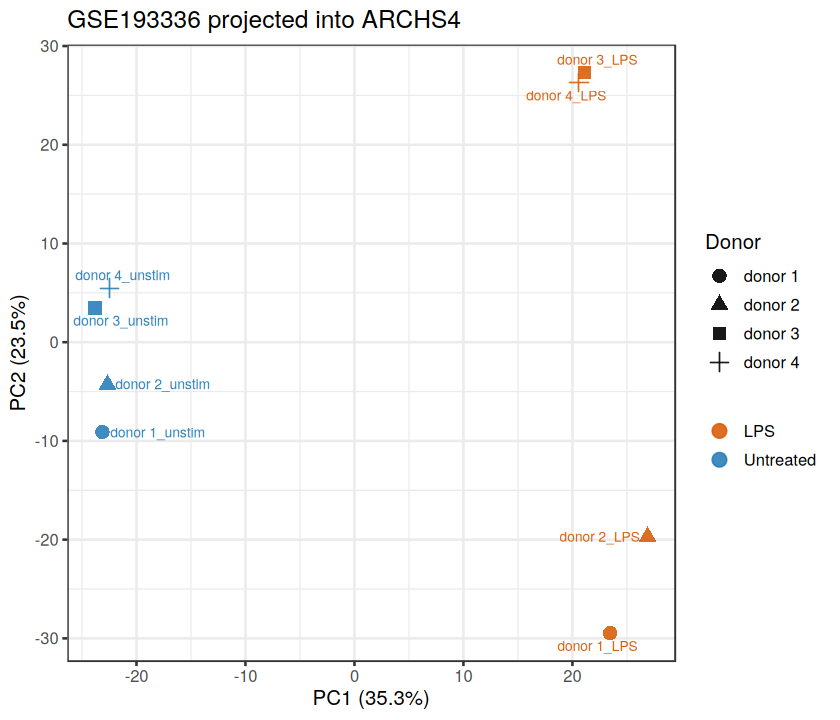

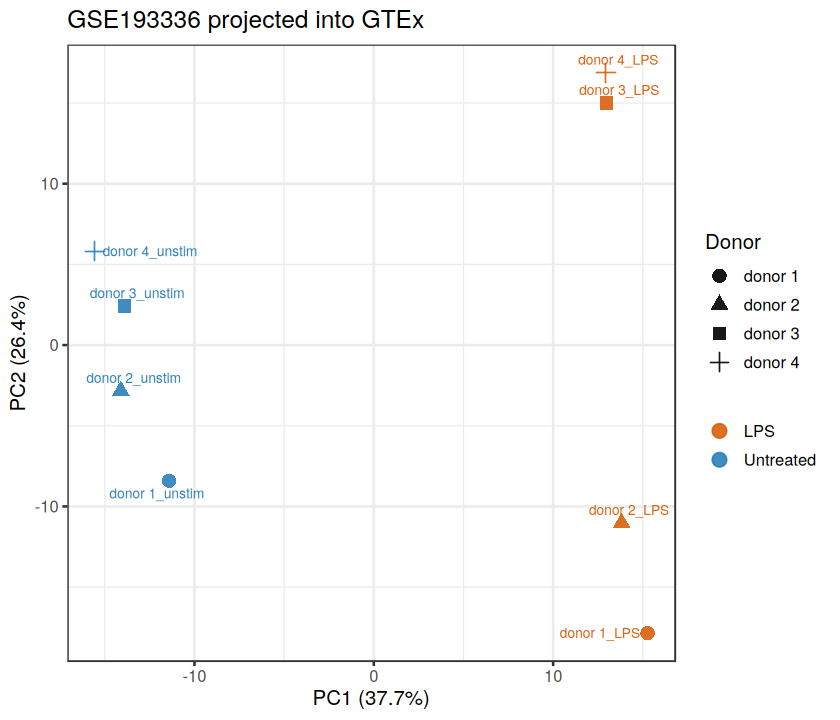

In [59]:
options(repr.plot.width = 7, repr.plot.height = 6)

for (model_name in names(B_list)) {
  p <- make_pca_plot(B_list[[model_name]], meta_mac,
                     title = paste0("GSE193336 projected into ", model_name))
  print(p)
  ggsave(file.path(figure_dir, paste0("pca_", model_name, ".png")),
         plot = p, width = 7, height = 6, dpi = 150)
}


## Paired LPS vs untreated contrasts on projected LV scores

In [60]:
ranked_lvs <- lapply(names(models), function(model_name) {
  rank_lvs_paired(B = B_list[[model_name]],
                  meta = meta_mac,
                  mdl = models[[model_name]],
                  model_name = model_name)
})
names(ranked_lvs) <- names(models)

for (model_name in names(ranked_lvs)) {
  ranked_tbl <- ranked_lvs[[model_name]]
  write.csv(ranked_tbl,
            file.path(results_dir, paste0(model_name, "_LPS_vs_untreated_projected_LVs.csv")),
            row.names = FALSE)

  n_up <- sum(ranked_tbl$adj.P.Val < LV_FDR_CUTOFF &
                ranked_tbl$abs_logFC >= LV_LOGFC_CUTOFF & ranked_tbl$logFC > 0)
  n_dn <- sum(ranked_tbl$adj.P.Val < LV_FDR_CUTOFF &
                ranked_tbl$abs_logFC >= LV_LOGFC_CUTOFF & ranked_tbl$logFC < 0)
  cat(model_name, "selected LVs:",
      "higher in LPS =", n_up,
      "| higher in untreated =", n_dn, "\n")
}


ARCHS4 selected LVs: higher in LPS = 15 | higher in untreated = 24 
GTEx selected LVs: higher in LPS = 60 | higher in untreated = 54 


### Volcano plots

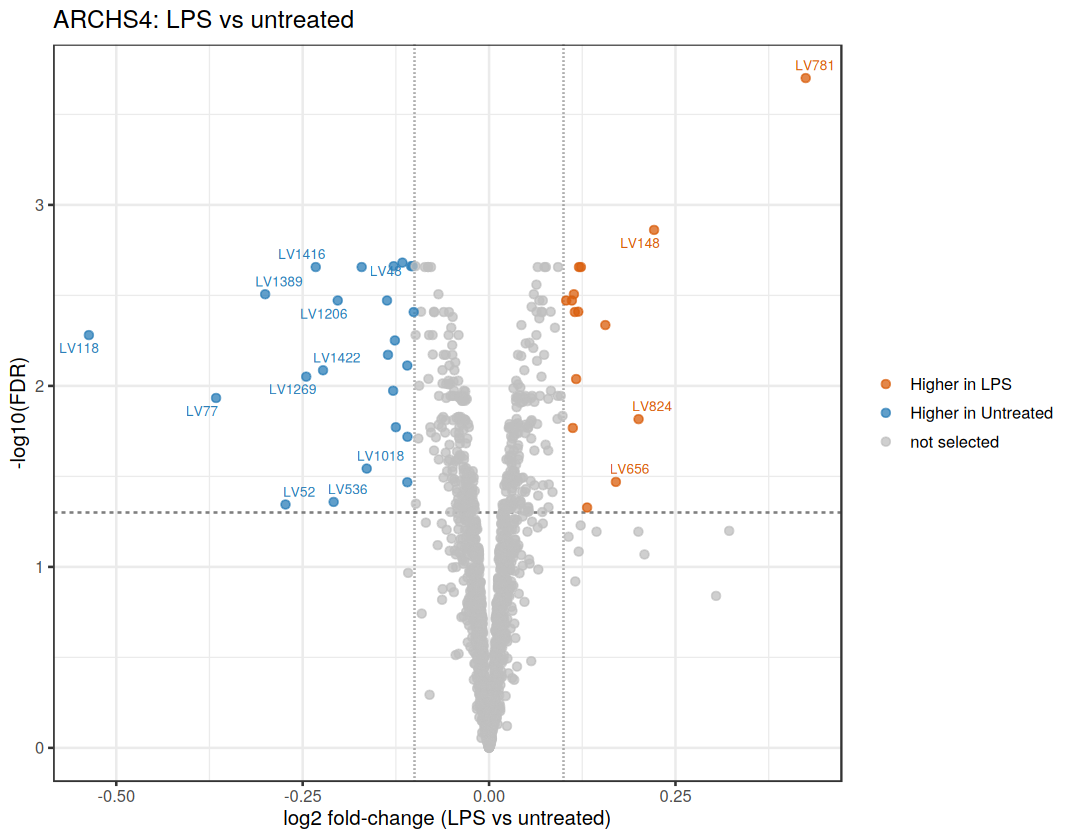

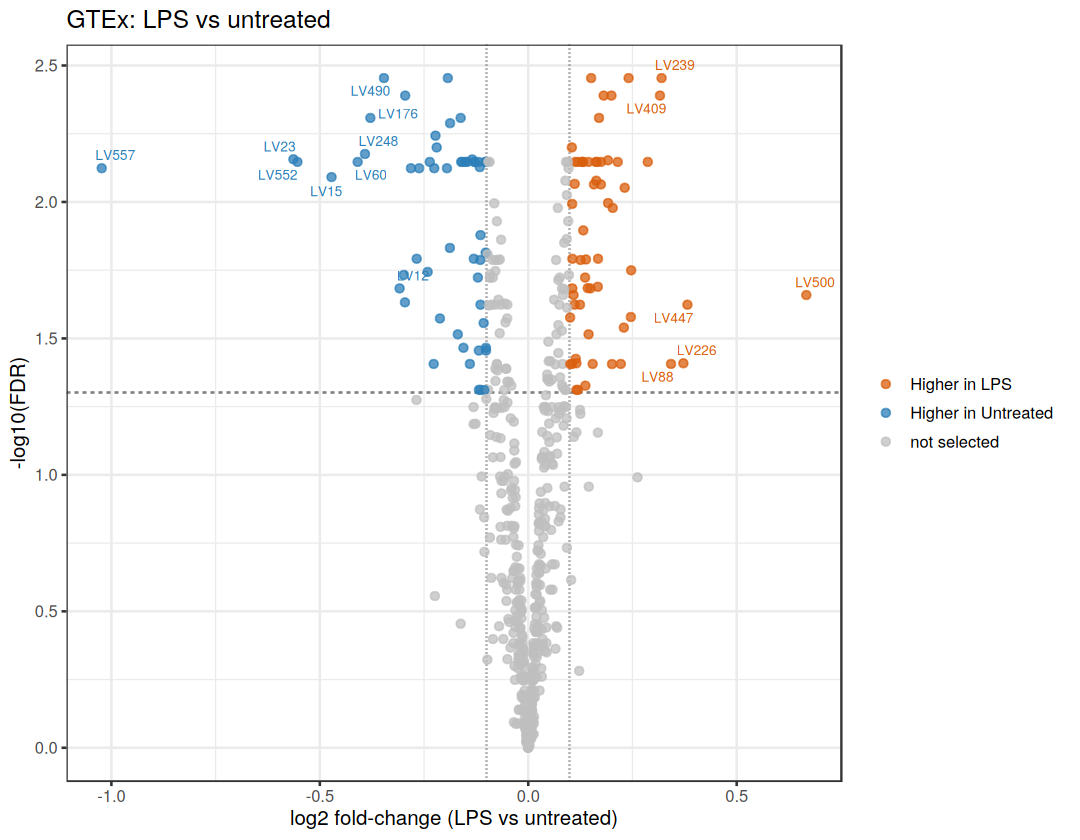

In [61]:
options(repr.plot.width = 9, repr.plot.height = 7)

for (model_name in names(ranked_lvs)) {
  p <- make_volcano(ranked_lvs[[model_name]],
                    title = paste0(model_name, ": LPS vs untreated"))
  print(p)
  ggsave(file.path(figure_dir, paste0("volcano_", model_name, ".png")),
         plot = p, width = 9, height = 7, dpi = 150)
}


### Selected LV tables

In [62]:
selected_lvs <- dplyr::bind_rows(ranked_lvs) %>%
  dplyr::filter(adj.P.Val < LV_FDR_CUTOFF, abs_logFC >= LV_LOGFC_CUTOFF) %>%
  dplyr::arrange(model, adj.P.Val, dplyr::desc(abs_logFC))

write.csv(selected_lvs,
          file.path(results_dir, "selected_projected_LVs_ARCHS4_and_GTEx.csv"),
          row.names = FALSE)

selected_lvs %>%
  dplyr::select(model, LV, logFC, adj.P.Val, direction, top_AUC, n_paths, pathways) %>%
  dplyr::group_by(model) %>%
  dplyr::slice_head(n = 20)


model,LV,logFC,adj.P.Val,direction,top_AUC,n_paths,pathways
<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>
ARCHS4,LV781,0.4246731,0.0001991255,Higher in LPS,0.8064262,1,OTHER ORGANISM PART
ARCHS4,LV148,0.2212949,0.0013745869,Higher in LPS,0.9659265,2,TUMOR NECROSIS FACTOR RECEPTOR SUPERFAMILY COMPLEX | TP53 REGULATES TRANSCRIPTION OF DEATH RECEPTORS AND LIGANDS
ARCHS4,LV1186,-0.1162656,0.0020841392,Higher in Untreated,0.0000000,0,unannotated
ARCHS4,LV1259,-0.1279057,0.0021797144,Higher in Untreated,0.9637665,1,SYNTHESIS OF GLYCOSYLPHOSPHATIDYLINOSITOL GPI
ARCHS4,LV1405,-0.1045163,0.0021797144,Higher in Untreated,0.8315850,1,TGFBR3 EXPRESSION
ARCHS4,LV485,-0.1025215,0.0021797144,Higher in Untreated,0.0000000,0,unannotated
ARCHS4,LV1416,-0.2324531,0.0022046876,Higher in Untreated,0.9947729,5,DISEASES OF BRANCHED CHAIN AMINO ACID CATABOLISM | MITOCHONDRIAL FATTY ACID BETA OXIDATION OF SATURATED FATTY ACIDS | BRANCHED CHAIN AMINO ACID CATABOLISM | MITOCHONDRIAL FATTY ACID BETA OXIDATION | PEROXISOMAL LIPID METABOLISM
ARCHS4,LV48,-0.1708785,0.0022046876,Higher in Untreated,0.0000000,0,unannotated
ARCHS4,LV762,0.1231397,0.0022046876,Higher in LPS,0.0000000,0,unannotated


## Pathways inferred from selected projected LVs

In [63]:
pathway_hits <- dplyr::bind_rows(lapply(names(models), function(model_name) {
  extract_shifted_pathways(ranked_lvs[[model_name]], models[[model_name]], model_name)
}))

pathway_summary <- summarise_shifted_pathways(pathway_hits)

for (model_name in names(models)) {
  write.csv(pathway_hits %>% dplyr::filter(model == model_name),
            file.path(results_dir, paste0(model_name, "_selected_LV_pathway_hits.csv")),
            row.names = FALSE)
  write.csv(pathway_summary %>% dplyr::filter(model == model_name),
            file.path(results_dir, paste0(model_name, "_selected_pathway_summary.csv")),
            row.names = FALSE)
}

cat("Annotated pathway hits:", nrow(pathway_hits), "\n")
pathway_summary %>%
  dplyr::group_by(model, direction) %>%
  dplyr::summarise(n_pathways = dplyr::n_distinct(pathway_clean), .groups = "drop")


Annotated pathway hits: 305 


model,direction,n_pathways
<chr>,<chr>,<int>
ARCHS4,Higher in LPS,27
ARCHS4,Higher in Untreated,52
GTEx,Higher in LPS,79
GTEx,Higher in Untreated,126


### Signed shifted pathway plots

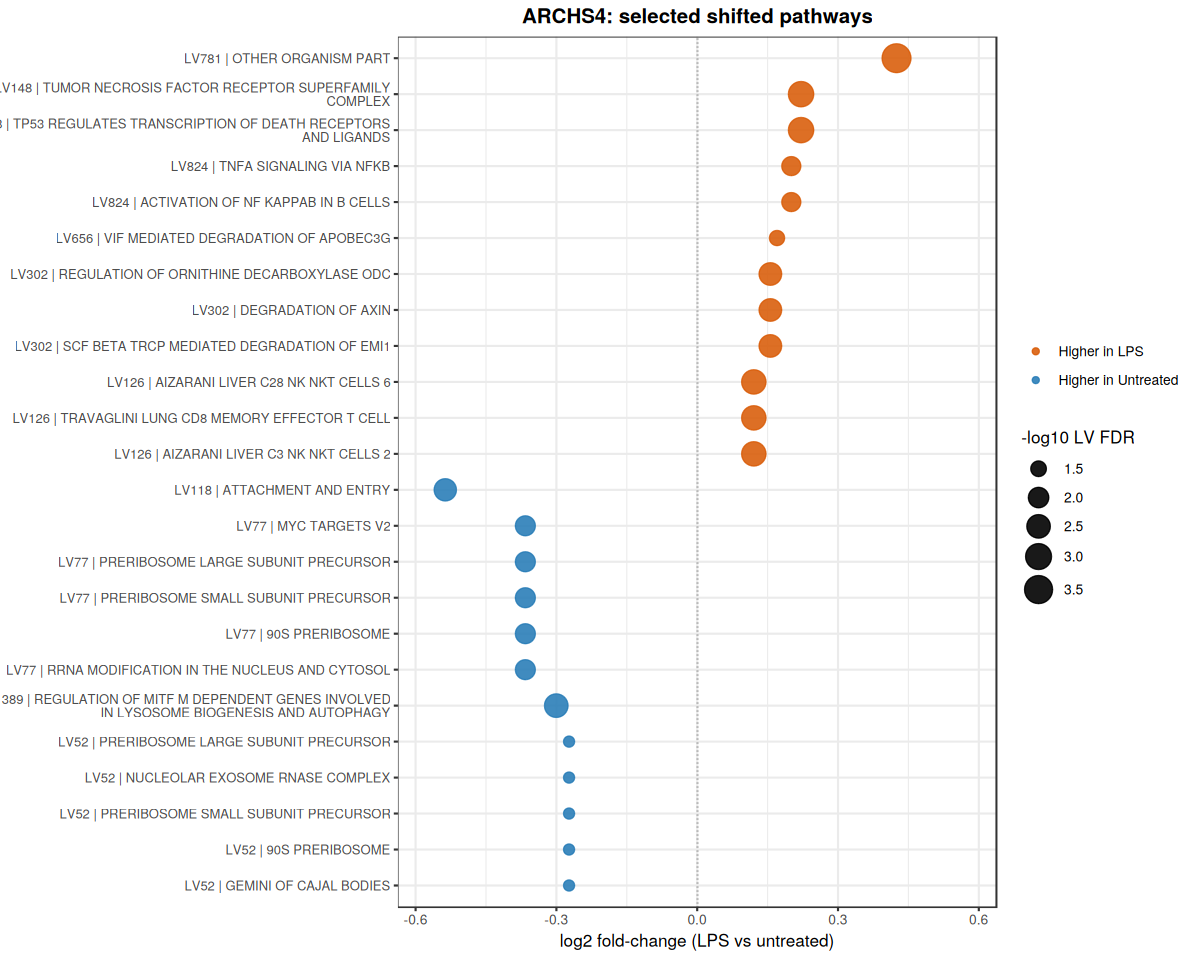

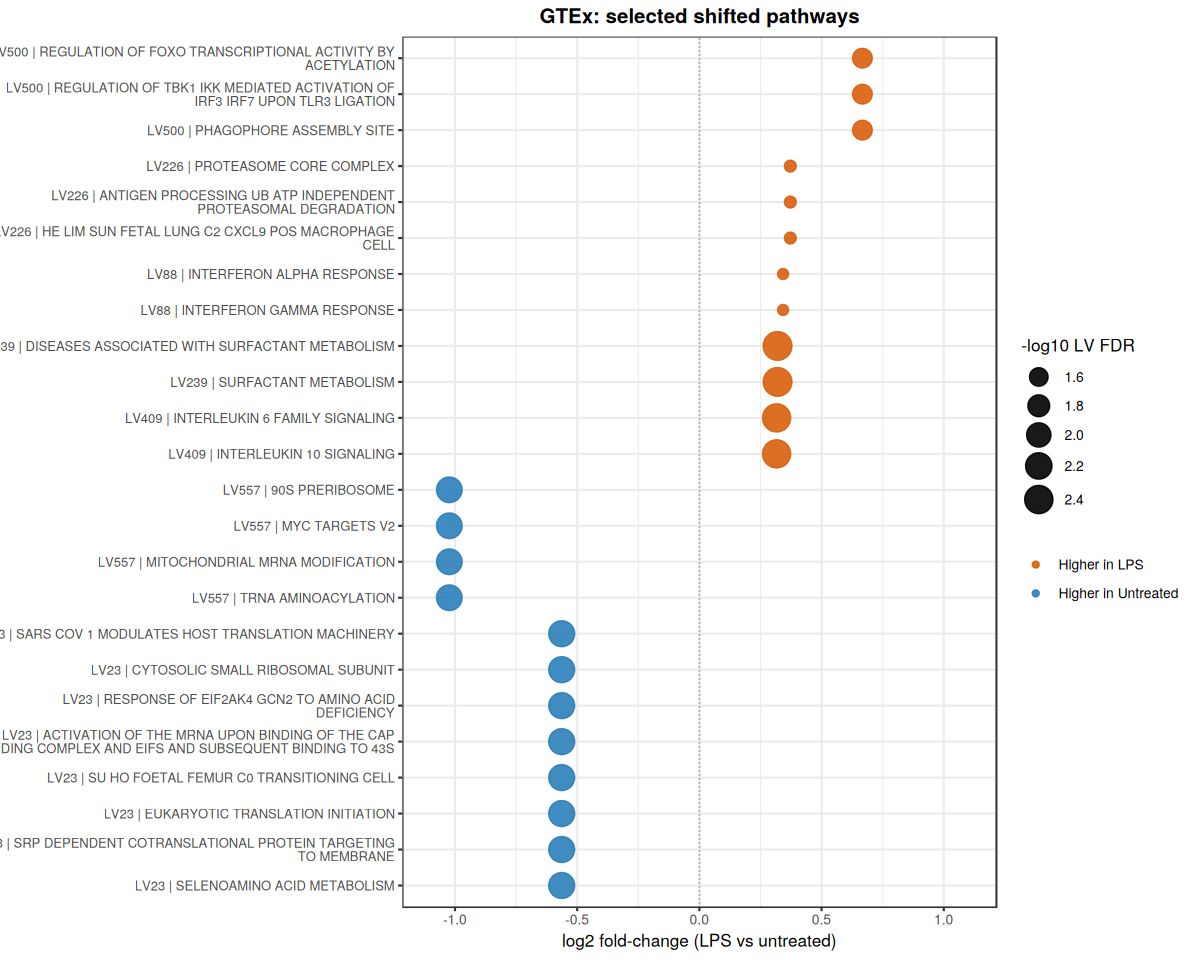

In [64]:
options(repr.plot.width = 10, repr.plot.height = 8)

for (model_name in names(models)) {
  p <- make_pathway_shift_plot(pathway_hits, model_name, top_n_per_direction = 12)
  print(p)
  ggsave(file.path(figure_dir, paste0("shifted_pathways_", model_name, ".png")),
         plot = p, width = 10, height = 8, dpi = 150)
}


## Compare ARCHS4 and GTEx inferred pathways

In [65]:
collapse_model_pathways <- function(pathway_summary, model_name) {
  empty_model_paths <- data.frame(
    pathway_clean = character(),
    direction = character(),
    n_lvs = integer(),
    max_abs_logFC = numeric(),
    min_lv_FDR = numeric(),
    best_AUC = numeric(),
    LVs = character(),
    stringsAsFactors = FALSE
  )

  if (nrow(pathway_summary) == 0 || !model_name %in% pathway_summary$model) {
    return(empty_model_paths)
  }

  pathway_summary %>%
    dplyr::filter(model == model_name) %>%
    dplyr::group_by(pathway_clean) %>%
    dplyr::summarise(
      direction = paste(sort(unique(direction)), collapse = "; "),
      n_lvs = sum(n_lvs),
      max_abs_logFC = max(max_abs_logFC, na.rm = TRUE),
      min_lv_FDR = min(min_lv_FDR, na.rm = TRUE),
      best_AUC = max(best_AUC, na.rm = TRUE),
      LVs = paste(unique(LVs), collapse = ", "),
      .groups = "drop"
    )
}

archs4_paths <- collapse_model_pathways(pathway_summary, "ARCHS4") %>%
  dplyr::rename(
    ARCHS4_direction = direction,
    ARCHS4_n_lvs = n_lvs,
    ARCHS4_max_abs_logFC = max_abs_logFC,
    ARCHS4_min_lv_FDR = min_lv_FDR,
    ARCHS4_best_AUC = best_AUC,
    ARCHS4_LVs = LVs
  )

gtex_paths <- collapse_model_pathways(pathway_summary, "GTEx") %>%
  dplyr::rename(
    GTEx_direction = direction,
    GTEx_n_lvs = n_lvs,
    GTEx_max_abs_logFC = max_abs_logFC,
    GTEx_min_lv_FDR = min_lv_FDR,
    GTEx_best_AUC = best_AUC,
    GTEx_LVs = LVs
  )

comparison_tbl <- dplyr::full_join(archs4_paths, gtex_paths, by = "pathway_clean") %>%
  dplyr::mutate(
    shared = !is.na(ARCHS4_direction) & !is.na(GTEx_direction),
    direction_agreement = dplyr::case_when(
      !shared ~ "model-specific",
      ARCHS4_direction == GTEx_direction ~ "same",
      TRUE ~ "mixed or opposite"
    ),
    max_evidence = pmax(ARCHS4_max_abs_logFC, GTEx_max_abs_logFC, na.rm = TRUE)
  ) %>%
  dplyr::arrange(dplyr::desc(shared), direction_agreement,
                 dplyr::desc(max_evidence), pathway_clean)

write.csv(comparison_tbl,
          file.path(results_dir, "ARCHS4_GTEx_inferred_pathway_comparison.csv"),
          row.names = FALSE)

cat("ARCHS4 pathways:", nrow(archs4_paths), "\n")
cat("GTEx pathways:", nrow(gtex_paths), "\n")
cat("Shared pathways:", sum(comparison_tbl$shared), "\n")

comparison_tbl %>%
  dplyr::count(shared, direction_agreement)


ARCHS4 pathways: 76 
GTEx pathways: 198 
Shared pathways: 32 


shared,direction_agreement,n
<lgl>,<chr>,<int>
FALSE,model-specific,210
TRUE,mixed or opposite,5
TRUE,same,27


## Related PhenoMeXcan traits for selected shifted LVs

In [69]:
trait_tables <- lapply(names(trait_paths), function(model_name) {
  load_model_traits(trait_paths[[model_name]], model_name)
})
names(trait_tables) <- names(trait_paths)

for (model_name in names(trait_tables)) {
  cat(model_name, "traits:", nrow(trait_tables[[model_name]]),
      "rows |", dplyr::n_distinct(trait_tables[[model_name]]$phenotype_id),
      "phenotypes |", dplyr::n_distinct(trait_tables[[model_name]]$LV), "LVs\n")
}

trait_hits <- dplyr::bind_rows(lapply(names(trait_tables), function(model_name) {
  get_related_traits(ranked_lvs[[model_name]], trait_tables[[model_name]])
}))

trait_summary <- summarise_related_traits(trait_hits)

for (model_name in names(trait_tables)) {
  write.csv(trait_hits %>% dplyr::filter(model == model_name),
            file.path(results_dir, paste0(model_name, "_selected_LV_trait_hits.csv")),
            row.names = FALSE)
  write.csv(trait_summary %>% dplyr::filter(model == model_name),
            file.path(results_dir, paste0(model_name, "_selected_trait_summary.csv")),
            row.names = FALSE)
}

cat("Related trait hits:", nrow(trait_hits), "\n")
trait_summary %>%
  dplyr::group_by(model, direction) %>%
  dplyr::summarise(n_traits = dplyr::n_distinct(phenotype_id), .groups = "drop")


ARCHS4 traits: 6996672 rows | 4049 phenotypes | 1728 LVs
GTEx traits: 2340322 rows | 4049 phenotypes | 578 LVs
Related trait hits: 590 


model,direction,n_traits
<chr>,<chr>,<int>
ARCHS4,Higher in LPS,55
ARCHS4,Higher in Untreated,48
GTEx,Higher in LPS,233
GTEx,Higher in Untreated,115


In [83]:
trait_hits %>%
  dplyr::filter(
    model == "ARCHS4",
    grepl("arthritis", phenotype, ignore.case = TRUE)
  ) %>%
  dplyr::select(LV, phenotype, trait_FDR, logFC) %>%
  dplyr::arrange(dplyr::desc(logFC)) %>%
  print()

      LV                                                    phenotype trait_FDR
1  LV354       Non-cancer illness code, self-reported: osteoarthritis 0.0494128
2 LV1018                                         Rheumatoid arthritis 0.0347197
3 LV1018 Non-cancer illness code, self-reported: rheumatoid arthritis 0.0366444
4 LV1018       Diagnoses - main ICD10: M06 Other rheumatoid arthritis 0.0391895
5 LV1018                       Other/unspecified rheumatoid arthritis 0.0468462
       logFC
1  0.1167762
2 -0.1640967
3 -0.1640967
4 -0.1640967
5 -0.1640967


### Trait dataframe for significant LVs by direction

In [70]:
sig_lv_traits_control_cyt <- trait_hits %>%
  dplyr::mutate(
    projection = model,
    condition_group = dplyr::case_when(
      direction == "Higher in Untreated" ~ "control",
      direction == "Higher in LPS" ~ "cyt",
      TRUE ~ "other"
    ),
    lv_log2FC_cyt_vs_control = logFC,
    lv_FDR = adj.P.Val
  ) %>%
  dplyr::select(
    projection,
    condition_group,
    LV,
    lv_log2FC_cyt_vs_control,
    lv_FDR,
    phenotype_id,
    phenotype,
    trait_pvalue,
    trait_FDR,
    direction,
    pathways,
    top_AUC,
    n_paths
  ) %>%
  dplyr::arrange(projection, condition_group, lv_FDR, trait_FDR, dplyr::desc(abs(lv_log2FC_cyt_vs_control)))

write.csv(
  sig_lv_traits_control_cyt,
  file.path(results_dir, "sig_lv_traits_control_cyt_ARCHS4_GTEx.csv"),
  row.names = FALSE
)

sig_lv_traits_control_cyt %>%
  dplyr::group_by(projection, condition_group) %>%
  dplyr::summarise(
    n_lvs = dplyr::n_distinct(LV),
    n_traits = dplyr::n_distinct(phenotype_id),
    n_rows = dplyr::n(),
    .groups = "drop"
  )


projection,condition_group,n_lvs,n_traits,n_rows
<chr>,<chr>,<int>,<int>,<int>
ARCHS4,control,13,48,49
ARCHS4,cyt,13,55,61
GTEx,control,38,115,141
GTEx,cyt,45,233,339


## Export for Figure 4

In [ ]:
PANEL_DIR_FIG4 <- here('output/99_panels/fig4')
dir.create(PANEL_DIR_FIG4, recursive = TRUE, showWarnings = FALSE)

# Pathway summaries per model
write.csv(
  pathway_summary %>% dplyr::filter(model == "ARCHS4"),
  file.path(PANEL_DIR_FIG4, 'macrophage_archs4_pathway_summary.csv'), row.names = FALSE
)
write.csv(
  pathway_summary %>% dplyr::filter(model == "GTEx"),
  file.path(PANEL_DIR_FIG4, 'macrophage_gtex_pathway_summary.csv'), row.names = FALSE
)

# Cross-model pathway comparison
write.csv(
  comparison_tbl,
  file.path(PANEL_DIR_FIG4, 'macrophage_pathway_comparison.csv'), row.names = FALSE
)

# Selected LV-level pathway hits (for bubble plots in fig4)
write.csv(
  pathway_hits %>% dplyr::filter(model == "ARCHS4"),
  file.path(PANEL_DIR_FIG4, 'macrophage_archs4_lv_pathway_hits.csv'), row.names = FALSE
)
write.csv(
  pathway_hits %>% dplyr::filter(model == "GTEx"),
  file.path(PANEL_DIR_FIG4, 'macrophage_gtex_lv_pathway_hits.csv'), row.names = FALSE
)

message("Exported macrophage data to ", PANEL_DIR_FIG4)